# Creating summary plots of empirical distributions from local data

In [2]:
bin_size = 0.001
seed = 42
model_conditions = {'drift_rate': 1.2, 'theta': 0.38, 'noise': 0.5}

In [34]:
import simulation

path = '/Users/braydenchien/Desktop/Enkavilab/DDM/1ms_trial_data.csv'
empirical_distributions = simulation.get_empirical_distributions(path, bin_size)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def _as_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    return np.asarray(x, dtype=float).ravel()

def _fix_lengths_per_key(fix_map):
    """
    fix_map: dict where keys are floats in [-4.0, 4.0] step 0.25
             and values are array-like (whose lengths we count).
    Returns (keys_sorted_float, lengths_per_key_as_float).
    """
    if not isinstance(fix_map, dict) or not fix_map:
        return np.array([], dtype=float), np.array([], dtype=float)
    # Sort keys numerically to keep the x-axis ordered
    keys = sorted(fix_map.keys(), key=float)
    lengths = [len(_as_1d_float_array(fix_map[k])) for k in keys]
    return np.array(keys, dtype=float), np.array(lengths, dtype=float)

def _set_sparse_xticks(ax, xs, every=4, rotation=0):
    """Show only every Nth tick to reduce clutter."""
    if xs.size == 0:
        return
    idx = np.arange(xs.size)
    show = (idx % every) == 0
    ax.set_xticks(xs[show])
    ax.set_xticklabels([f"{v:g}" for v in xs[show]], rotation=rotation)

def plot_empirical_distributions(ed, *, tick_every=4):
    """
    ed: dict with keys:
        - 'latencies': np.ndarray of floats
        - 'transitions': np.ndarray of floats
        - 'fixations': dict {1: dict{float_key: array}, 2: dict{float_key: array}}

    Creates a 2x2 figure:
      (1,1) histogram of ed['latencies']
      (1,2) histogram of ed['transitions']
      (2,1) bar chart: keys of fixations[1] on x, lengths of arrays as heights
      (2,2) bar chart: keys of fixations[2] on x, lengths of arrays as heights
    """
    latencies = _as_1d_float_array(ed.get('latencies', np.array([])))
    transitions = _as_1d_float_array(ed.get('transitions', np.array([])))

    fix = ed.get('fixations', {}) if isinstance(ed, dict) else {}
    fix1 = fix.get(1, {})
    fix2 = fix.get(2, {})

    keys1, lens1 = _fix_lengths_per_key(fix1)
    keys2, lens2 = _fix_lengths_per_key(fix2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax11, ax12, ax21, ax22 = axes.ravel()

    # Top row: true histograms (continuous/binning)
    ax11.hist(latencies, bins=40)
    ax11.set_title("Latencies")
    ax11.set_xlabel("Latency")
    ax11.set_ylabel("Count")

    ax12.hist(transitions, bins=40)
    ax12.set_title("Transitions")
    ax12.set_xlabel("Transition value")
    ax12.set_ylabel("Count")

    # Bottom row: fixed-bin “histograms” → bar charts at the exact key values
    if keys1.size:
        # width smaller than the 0.25 spacing to leave a small gap
        ax21.bar(keys1, lens1, width=0.20, align='center')
        ax21.set_xlim(keys1.min() - 0.2, keys1.max() + 0.2)
        _set_sparse_xticks(ax21, keys1, every=tick_every, rotation=90)
    ax21.set_title("First Fixations: count per key")
    ax21.set_xlabel("Signed Value Difference")
    ax21.set_ylabel("Count (length of array)")

    if keys2.size:
        ax22.bar(keys2, lens2, width=0.20, align='center')
        ax22.set_xlim(keys2.min() - 0.2, keys2.max() + 0.2)
        _set_sparse_xticks(ax22, keys2, every=tick_every, rotation=90)
    ax22.set_title("Second Fixations: count per key")
    ax22.set_xlabel("Signed Value Difference")
    ax22.set_ylabel("Count (length of array)")

    fig.suptitle("Empirical Distributions", y=0.98)
    fig.tight_layout()
    return fig, axes

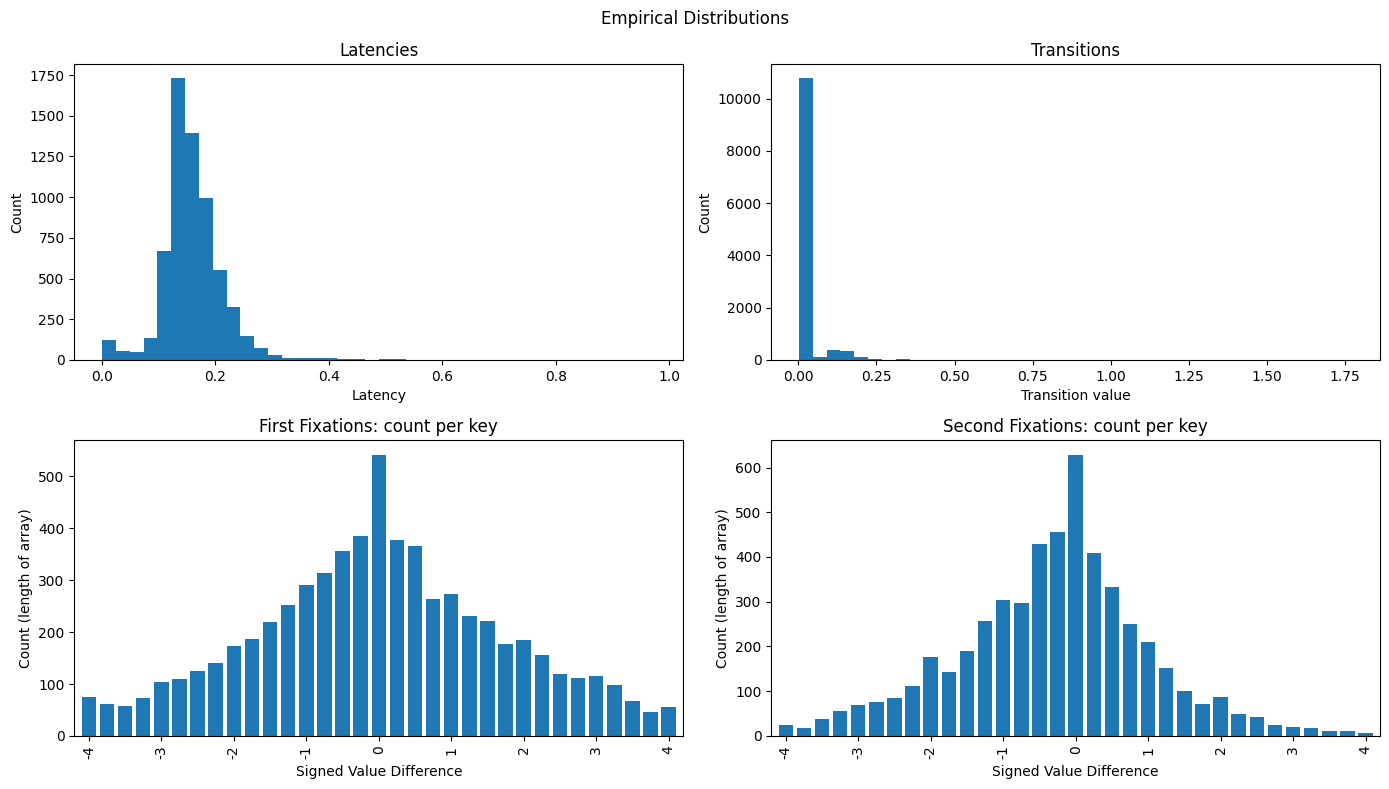

In [5]:
fig, axes = plot_empirical_distributions(empirical_distributions, tick_every=4)
plt.show()

# Creating summary plots of empirical distributions from Tavares project data

The original get empirical distributions is highly specialized for my intial exploration of data. No modifications were made to that part of the pipeline when it worked, but now, we need something more general. Several changes take place: 

- Takes in a DataFrame instead of a path
- Does not handle exclusions (aka, exclusions handled outside of empirical distributions)
- Fixations is already a numpy array and not a tuple encapsulated in string
- Lean DataFrame required including a fixations column, avgWTP_left, and avgWTP_right
- Generalize value_diffs

So the following workflow will:

1. Transform fixations using new `generate_fixations` function
2. Combine experimental and fixation data into one dataframe
3. Capture novel value diffs within `get_empirical_distributions`


## Transforming Fixations

First, we need a helper function to get from fixation location and duration into fixation location and fixation start and end times. I'll need to rename the existing helper functions in /Users/braydenchien/Desktop/Enkavilab/PyDDM/pyddm/preprocessing.

In [6]:
import pandas as pd

def fix_dur_to_fix_start_and_end(
    df: pd.DataFrame,
    fix_dur_col_name: str,
    trial_col_name: str,
    subject_col_name: str,
    start_col_name: str = "fix_start",
    end_col_name: str = "fix_end",
):
    """
    Compute inclusive start/end indices per (subject, trial).

    For each (subject, trial):
      - first fixation starts at 0 and ends at duration-1
      - next starts at prev_end + 1
    """
    if fix_dur_col_name not in df.columns:
        raise KeyError(f"Missing duration column: {fix_dur_col_name!r}")
    if trial_col_name not in df.columns:
        raise KeyError(f"Missing trial column: {trial_col_name!r}")
    if subject_col_name not in df.columns:
        raise KeyError(f"Missing subject column: {subject_col_name!r}")

    # Work on a copy
    work = df.copy()

    # Validate and drop zero/negative
    durations_all = pd.to_numeric(work[fix_dur_col_name], errors="coerce")
    if durations_all.isna().any():
        bad = work.index[durations_all.isna()].tolist()
        raise ValueError(
            f"{fix_dur_col_name!r} contains non-numeric values at indices {bad[:5]}..."
        )

    mask = durations_all > 0
    work = work.loc[mask].copy()
    durations = pd.to_numeric(work[fix_dur_col_name], errors="coerce")
    if (durations < 0).any():
        neg_idx = work.index[durations < 0].tolist()
        raise ValueError(
            f"{fix_dur_col_name!r} contains negative values at indices {neg_idx[:5]}..."
        )

    # Group by BOTH subject and trial
    keys = [work[subject_col_name], work[trial_col_name]]

    # starts = cumsum(shifted durations) within each (subject, trial)
    starts = (
        durations.groupby(keys)
        .apply(lambda s: s.shift(fill_value=0).cumsum())
        .reset_index(level=[0,1], drop=True)
    )

    ends = starts + durations - 1  # inclusive end

    work[start_col_name] = starts.astype("int64")
    work[end_col_name]   = ends.astype("int64")

    return work


In [7]:
import os

parent_dir = '/Users/braydenchien/Desktop/Enkavilab/aDDM-Toolbox/addm_toolbox/data'
fixations_path = os.path.join(parent_dir, 'fixations.csv')

fixations_df = pd.read_csv(fixations_path)

It turns out that there are several fixations with times of 0. I didn't yet investigate why this appears in data, nor how this actually happened (I'm guessing some sort of floor operator on a quick glance, all during saccades, which are encoded 3). For now, they are completely removed from the fixation numpy array.

In [8]:
fixations_df[fixations_df['fix_time'] == 0].head()

,parcode,trial,fix_item,fix_time
23519,2,935,3,0.0
38394,4,528,3,0.0
44428,5,115,3,0.0
46883,5,462,3,0.0
57874,6,875,3,0.0


In [9]:
reformatted_df = fix_dur_to_fix_start_and_end(fixations_df, 'fix_time', 'trial', 'parcode')

Now using `derasterize_functions`

In [10]:
from pyddm.preprocessing.dataset import derasterize_data

derasterized_df = derasterize_data(reformatted_df, "parcode", "trial", loc_col="fix_item")

   parcode  trial  fix_item  fix_time  fix_start  fix_end
0        0      0         3     176.0          0      175
1        0      0         0      42.0        176      217
2        0      0         1     188.0        218      405
3        0      0         0      72.0        406      477
4        0      0         2     582.0        478     1059
5        0      0         0      68.0       1060     1127
6        0      0         1     834.0       1128     1961


## Combining data

In [11]:
exp_path = os.path.join(parent_dir, 'expdata.csv')

exp_df = pd.read_csv(exp_path)

In [12]:
total_df = pd.concat([exp_df, derasterized_df], axis=1)
total_df = total_df.loc[:, ~total_df.columns.duplicated()]
total_df = total_df.drop(columns=["valid"])
total_df.shape

(31854, 8)

In [13]:
from addm_toolbox.util import convert_item_values

total_df['item_left'] = convert_item_values(total_df['item_left']).astype(int)
total_df['item_right'] = convert_item_values(total_df['item_right']).astype(int)

total_df.head()

,parcode,trial,rt,choice,item_left,item_right,fix_item,fix_sequence
0,0,0,1962.0,-1,0,3,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
1,0,1,2899.0,-1,1,0,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
2,0,2,1631.0,1,0,0,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
3,0,3,3203.0,-1,2,1,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
4,0,4,1181.0,1,1,1,3,"[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."


## Capture Novel Value Diffs

In [14]:
print(np.unique(total_df['item_left']))
print(np.unique(total_df['item_right']))

value_diffs = np.arange(-3, 4, 1)
value_diffs

[0 1 2 3]
[0 1 2 3]


array([-3, -2, -1,  0,  1,  2,  3])

In Brenden's dataset, the set of value differences is `np.arange(-4, 4.25, 0.25)`. In this function, we hope to detect them with `np.unique()`.

In [31]:
def get_empirical_distributions(
    df: pd.DataFrame,
    bin_size: float,
    value_diffs: list,
    *,
    legend: dict = None,
    fixation_col: str = None,
    v_left_col: str = "avgWTP_left",
    v_right_col: str = "avgWTP_right",
    trial_col: str = None,
    start_col: str = None,
    end_col: str = None,
    location_col: str = None,
    assume_bins: bool = True,
    num_fix_dists: int = 2,
    time_step: float | None = None,
    max_fix_time: float | None = None,
):
    """
    Compute empirical fixation duration, latency, and transition distributions
    from fixation sequences or fixation event tuples, with flexible legend mapping,
    customizable column names, and ordinal fixation buckets.

    Supports either:
        (A) rasterized fixation sequences per trial (via `fixation_col`), or
        (B) start–end–location tuples (via `start_col`, `end_col`, `location_col`, grouped by `trial_col`).

    Estimates:
      • Probability that the first fixation is on the left option
      • Distribution of latencies (time to first fixation)
      • Distribution of transition durations between fixations
      • Fixation duration distributions split by fixation ordinal (1..num_fix_dists,
        with the last bucket pooling Nth+), and binned by signed value difference
        (fixated − unfixated)

    Parameters
    ----------
    df : pandas.DataFrame
        Input data containing either rasterized fixation sequences or fixation events.

    bin_size : float
        Time represented by one element in a fixation sequence, in seconds (or any consistent unit).

    value_diffs : list of float
        The set of possible (or desired) signed value differences to bin by. Each fixation
        duration is assigned to the closest bin in this list.

    legend : dict, optional
        Mapping of raw fixation codes to categories. Example:
            legend = {
                "left": {1},
                "right": {2},
                "transition": {0, 3, 4},
                # "ignore": set()  # optional
            }
        Default: assumes 1 = left, 2 = right, and {0,3,4} = transitions.
        Values may be lists or sets; they’re normalized to sets internally.

    fixation_col : str, optional
        Column containing pre-rasterized fixation sequences (list/array of codes) per trial.
        If provided, `start_col`/`end_col`/`location_col` are ignored.

    v_left_col, v_right_col : str
        Column names for the left/right values per trial (default: "avgWTP_left", "avgWTP_right").

    trial_col : str, optional
        Trial identifier column. Required if reconstructing from events.

    start_col, end_col : str, optional
        Start and end indices (inclusive) for each event row if reconstructing from events.
        If `assume_bins=False`, they are treated as times and converted using `bin_size`.

    location_col : str, optional
        Side for each event row ('left'/'right' strings or codes resolvable via `legend`).

    assume_bins : bool, default True
        If True, start/end are integer bin indices; if False, they are times to be
        converted to indices via `bin_size`.

    num_fix_dists : int, default 2
        Number of ordinal fixation buckets. Buckets are 1..num_fix_dists; the last bucket
        pools all remaining fixations (e.g., with 3 → 1st, 2nd, and 3rd+).

    Returns
    -------
    dict
        {
            "probFixLeftFirst": float,
            "latencies": np.ndarray,        # pre-first-fixation durations
            "transitions": np.ndarray,      # post-first transition durations
            "fixations": {                  # ordinal -> value_diff_bin -> np.ndarray of durations
                1: {vd: np.ndarray, ...},
                2: {vd: np.ndarray, ...},
                ...
                num_fix_dists: {vd: np.ndarray, ...}
            }
        }
    """
    # ---------- Legend normalization ----------
    # Default now distinguishes 0 vs 3 explicitly
    if legend is None:
        legend = {"left": {1}, "right": {2}, "transition": {0}, "blank_fixation": {3}}
    Lset = set(legend.get("left", set()))
    Rset = set(legend.get("right", set()))
    Tset = set(legend.get("transition", {0}))   # codes that behave like 0 (transitions)
    Bset = set(legend.get("blank_fixation", {3}))   # codes that behave like 3 (do NOT count as transitions after first fix)
    ignore_set = set(legend.get("ignore", set()))

    def classify(code):
        if code in ignore_set:
            return None
        if code in Lset:
            return "L"
        if code in Rset:
            return "R"
        if code in Tset:
            return "T"
        if code in Bset:
            return "B"
        return "T"        # default any other encodings as a transition

    def closest_bin(x, bins):
        return min(bins, key=lambda b: abs(x - b))

    def rasterize_from_events(events_df):
        if events_df.empty:
            return np.array([], dtype=object)
        if assume_bins:
            start_idx = events_df[start_col].to_numpy(dtype=int)
            end_idx   = events_df[end_col].to_numpy(dtype=int)
        else:
            start_idx = np.floor(events_df[start_col].to_numpy() / bin_size).astype(int)
            end_idx   = np.floor(events_df[end_col].to_numpy() / bin_size).astype(int)
        L = int(np.max(end_idx)) + 1
        seq = np.empty(L, dtype=object)
        seq[:] = None
        locs = events_df[location_col].to_numpy()
        for s, e, loc in zip(start_idx, end_idx, locs):
            if isinstance(loc, str):
                key = loc.strip().lower()
                code = "left" if key == "left" else ("right" if key == "right" else loc)
            else:
                code = loc
            seq[s:e+1] = code
        mask_none = (seq == None)  # noqa: E711
        if mask_none.any():
            seq[mask_none] = 0
        return seq

    # ---------- Output containers ----------
    valueDiffs = list(value_diffs)
    fixations_dict = {k: {v: [] for v in valueDiffs} for k in range(1, num_fix_dists + 1)}
    latencies_list, transitions_list = [], []
    count_left_first = 0
    count_total_first = 0

    # ---------- Iterate trials ----------
    if fixation_col is not None:
        trial_iter = df.itertuples(index=False)
        get_seq = lambda row: getattr(row, fixation_col)
        get_vL = lambda row: getattr(row, v_left_col)
        get_vR = lambda row: getattr(row, v_right_col)
    else:
        if not all([trial_col, start_col, end_col, location_col]):
            raise ValueError("To reconstruct from events, provide trial_col, start_col, end_col, and location_col.")
        grouped = df.groupby(trial_col, sort=False)
        def event_trial_iter():
            for trial_id, g in grouped:
                if v_left_col not in g or v_right_col not in g:
                    raise ValueError(f"Missing {v_left_col}/{v_right_col} for trial {trial_id}.")
                vL = g.iloc[0][v_left_col]
                vR = g.iloc[0][v_right_col]
                seq = rasterize_from_events(g)
                yield trial_id, seq, vL, vR
        trial_iter = event_trial_iter()
        get_seq = lambda item: item[1]
        get_vL  = lambda item: item[2]
        get_vR  = lambda item: item[3]

    for row in trial_iter:
        raw_seq = np.asarray(get_seq(row), dtype=object)
        if raw_seq.size == 0:
            continue

        # Classify each bin
        cls = np.array([classify(c) for c in raw_seq], dtype=object)
        keep = cls != None  # noqa: E711
        if not np.any(keep):
            continue
        cls = cls[keep]

        v_left  = float(get_vL(row))
        v_right = float(get_vR(row))
        sv_lookup = {"L": v_left - v_right, "R": v_right - v_left}

        lr_idx = np.flatnonzero((cls == "L") | (cls == "R"))
        if lr_idx.size <= 1:
            continue

        # Exclude the final censored L/R run from the tail
        exclude = np.zeros(cls.size, dtype=bool)
        last_i = lr_idx[-1]
        last_label = cls[last_i]
        j = last_i
        while j >= 0 and cls[j] == last_label:
            exclude[j] = True
            j -= 1
        exclude[last_i + 1 :] = True

        # Iterate runs (NOTE: with N0 vs N3, these do NOT merge)
        N = cls.size
        i = 0
        first_fix_reached = False
        latency_time = 0.0
        fix_number = 1

        while i < N:
            if exclude[i]:
                i += 1
                continue

            lab = cls[i]

            # grow contiguous run of same 'lab' (skipping excluded positions)
            start = i
            i += 1
            while i < N and (exclude[i] or cls[i] == lab):
                i += 1

            # run length in included bins
            run_len = np.count_nonzero(~exclude[start:i])
            if run_len == 0:
                continue
            dur = run_len * bin_size

            if lab in ("L", "R"):
                if not first_fix_reached:
                    first_fix_reached = True
                    count_total_first += 1
                    if lab == "L":
                        count_left_first += 1
                    latencies_list.append(latency_time)

                b = closest_bin(sv_lookup[lab], valueDiffs)
                bucket = min(fix_number, num_fix_dists)
                fixations_dict[bucket][b].append(dur)
                fix_number += 1

            elif lab in ("T", "B"):
                # BEFORE first fixation: both T and B contribute to latency
                if not first_fix_reached:
                    latency_time += dur
                else:
                    # AFTER first fixation: treat each T or B run as its own transition
                    ok_lo = (time_step is None) or (dur >= time_step)
                    ok_hi = (max_fix_time is None) or (dur <= max_fix_time)
                    if ok_lo and ok_hi:
                        transitions_list.append(dur)

        prob_fix_left_first = (count_left_first / count_total_first) if count_total_first > 0 else np.nan

    return {
        "probFixLeftFirst": prob_fix_left_first,
        "latencies": np.array(latencies_list, dtype=float),
        "transitions": np.array(transitions_list, dtype=float),
        "fixations": {
            k: {kk: np.array(vv, dtype=float) for kk, vv in v.items()}
            for k, v in fixations_dict.items()
        }
    }

In [16]:
bin_size = 1 # because the data is in milliseconds and there is no need to resample
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, "blank_fixation": {3}
}
fix_col = 'fix_sequence'
left_value_col = 'item_left'
right_value_col = 'item_right'

empirical_distributions = get_empirical_distributions(
    total_df, 
    bin_size, 
    value_diffs, 
    legend=legend, 
    fixation_col=fix_col, 
    v_left_col=left_value_col, 
    v_right_col=right_value_col,
    num_fix_dists=3,
    time_step=10,
    max_fix_time=3000
)

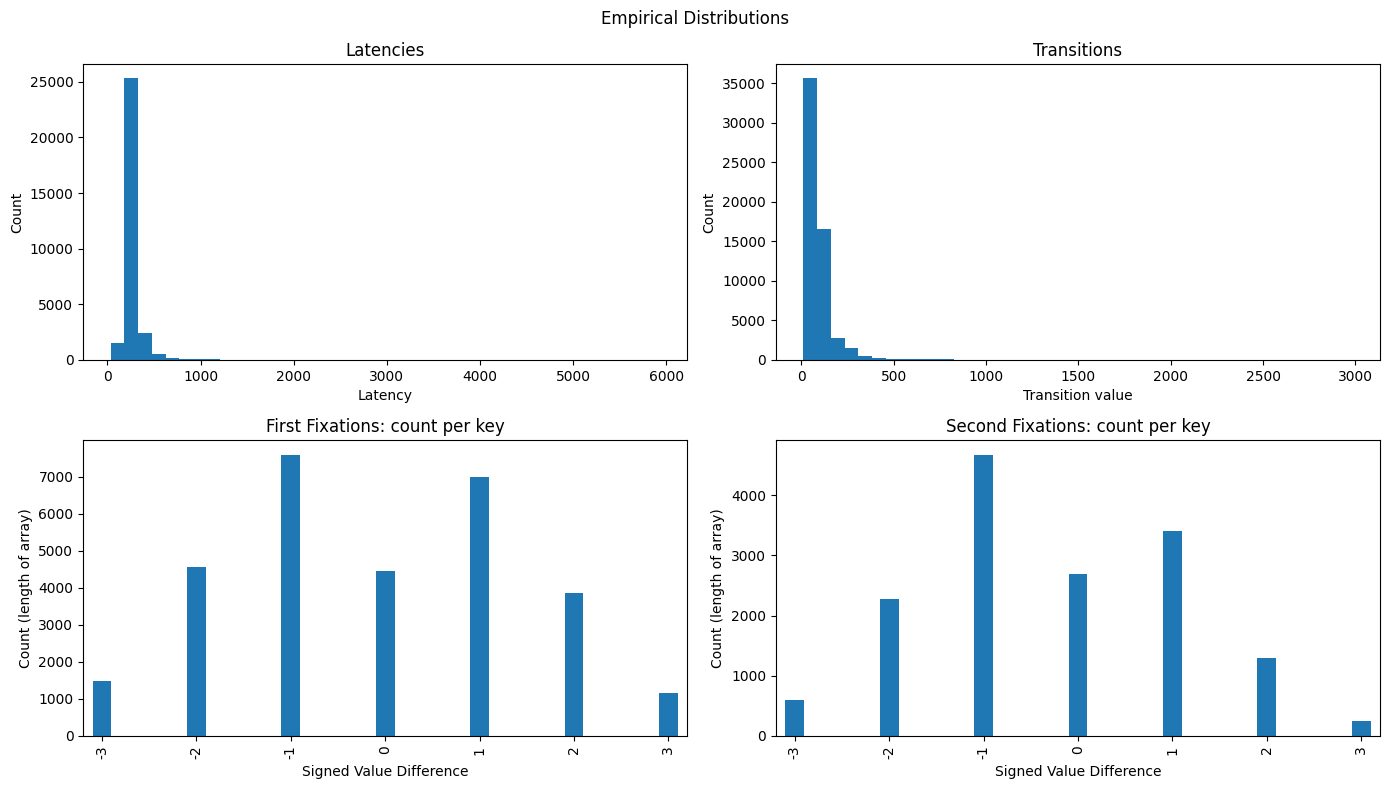

In [17]:
fig, axes = plot_empirical_distributions(empirical_distributions, tick_every=1)
plt.show()

There are some black swan observations in my reconstruction of get_empirical_distributions but they are insanely few in number (2 out of 30k) that adding this feature would not make much of a difference. If it does ever show up in data (fixations longer than 3 seconds), we'll know why, but that is an insane expectation. This is also why I plot histograms of counts and not actual descriptions of the center and spread of fixation durations. This fact will not affect our comparison of the two get_empirical_distributions.

In [18]:
print(sum(list(x < 10 or x > 3000 for x in empirical_distributions['transitions'])))
print(len(empirical_distributions['transitions']))

0
57705


# Creating summary plots from Tavares project data with aDDM_Toolbox

In [19]:
from addm_toolbox.util import *

# trial_conditions_path = os.path.join(parent_dir, "trial_conditions.csv")

# T_trial_conditions_df = load_trial_conditions_from_csv(trial_conditions_path)
T_df = load_data_from_csv(exp_path, fixations_path, convert_item_values)

In [20]:
from addm_toolbox.util import get_empirical_distributions as T_get_empirical_distributions

T_empirical_distributions = T_get_empirical_distributions(T_df)

Since Tavares' empirical_distributions object has a slightly different structure, I define a set of functions to traverse the object

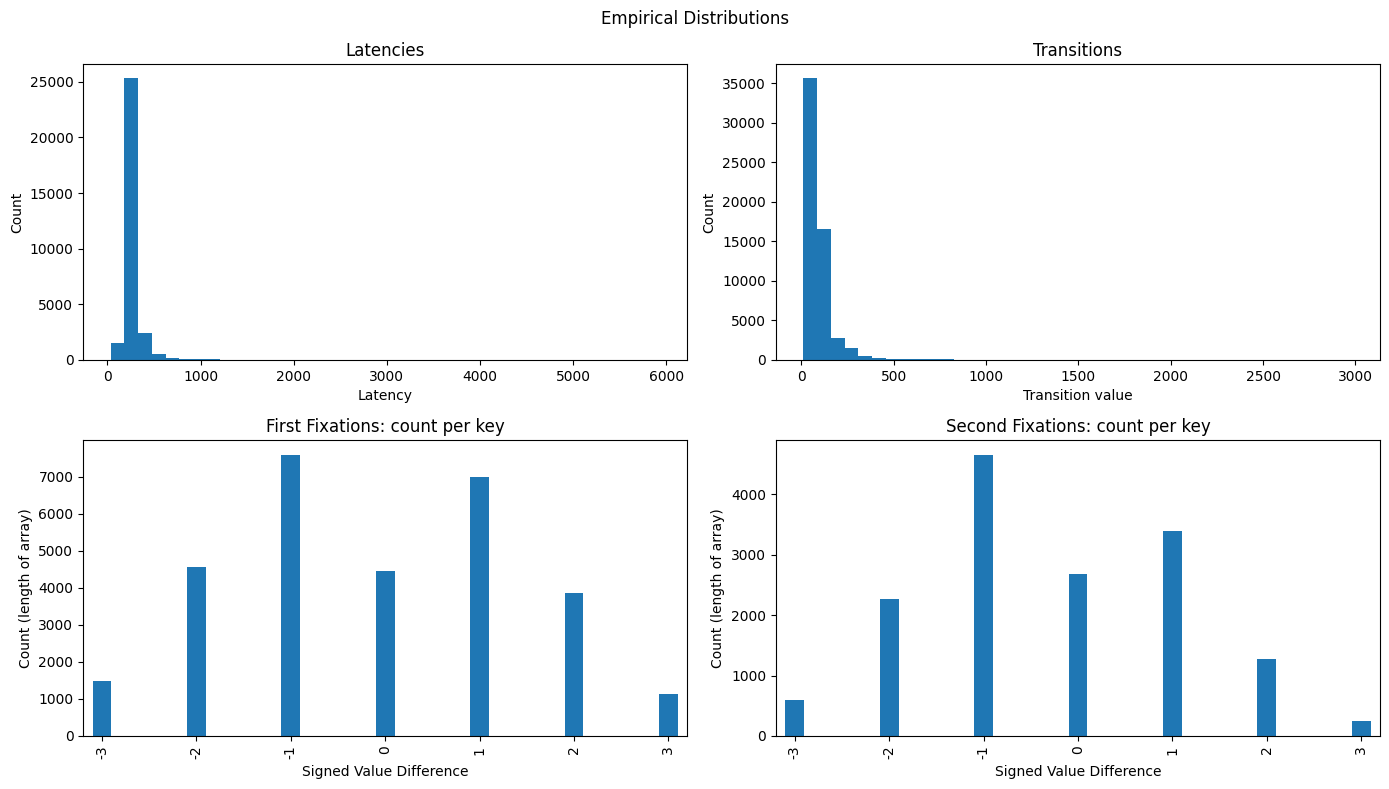

In [21]:
def T_as_1d_float_array(x):
    if x is None:
        return np.array([], dtype=float)
    return np.asarray(x, dtype=float).ravel()

def T_fix_lengths_per_key(fix_map):
    """
    fix_map: dict where keys are floats in [-4.0, 4.0] step 0.25
             and values are array-like (whose lengths we count).
    Returns (keys_sorted_float, lengths_per_key_as_float).
    """
    if not isinstance(fix_map, dict) or not fix_map:
        return np.array([], dtype=float), np.array([], dtype=float)
    # Sort keys numerically to keep the x-axis ordered
    keys = sorted(fix_map.keys(), key=float)
    lengths = [len(_as_1d_float_array(fix_map[k])) for k in keys]
    return np.array(keys, dtype=float), np.array(lengths, dtype=float)

def T_plot_empirical_distributions(ed, *, tick_every=4):
    """
    ed: dict with keys:
        - 'latencies': np.ndarray of floats
        - 'transitions': np.ndarray of floats
        - 'fixations': dict {1: dict{float_key: array}, 2: dict{float_key: array}}

    Creates a 2x2 figure:
      (1,1) histogram of ed['latencies']
      (1,2) histogram of ed['transitions']
      (2,1) bar chart: keys of fixations[1] on x, lengths of arrays as heights
      (2,2) bar chart: keys of fixations[2] on x, lengths of arrays as heights
    """
    latencies = T_as_1d_float_array(np.array(ed.latencies))
    transitions = T_as_1d_float_array(np.array(ed.transitions))

    fix = ed.fixations
    fix1 = fix.get(1, {})
    fix2 = fix.get(2, {})

    keys1, lens1 = T_fix_lengths_per_key(fix1)
    keys2, lens2 = T_fix_lengths_per_key(fix2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax11, ax12, ax21, ax22 = axes.ravel()

    # Top row: true histograms (continuous/binning)
    ax11.hist(latencies, bins=40)
    ax11.set_title("Latencies")
    ax11.set_xlabel("Latency")
    ax11.set_ylabel("Count")

    ax12.hist(transitions, bins=40)
    ax12.set_title("Transitions")
    ax12.set_xlabel("Transition value")
    ax12.set_ylabel("Count")

    # Bottom row: fixed-bin “histograms” → bar charts at the exact key values
    if keys1.size:
        # width smaller than the 0.25 spacing to leave a small gap
        ax21.bar(keys1, lens1, width=0.20, align='center')
        ax21.set_xlim(keys1.min() - 0.2, keys1.max() + 0.2)
        _set_sparse_xticks(ax21, keys1, every=tick_every, rotation=90)
    ax21.set_title("First Fixations: count per key")
    ax21.set_xlabel("Signed Value Difference")
    ax21.set_ylabel("Count (length of array)")

    if keys2.size:
        ax22.bar(keys2, lens2, width=0.20, align='center')
        ax22.set_xlim(keys2.min() - 0.2, keys2.max() + 0.2)
        _set_sparse_xticks(ax22, keys2, every=tick_every, rotation=90)
    ax22.set_title("Second Fixations: count per key")
    ax22.set_xlabel("Signed Value Difference")
    ax22.set_ylabel("Count (length of array)")

    fig.suptitle("Empirical Distributions", y=0.98)
    fig.tight_layout()
    return fig, axes

fig, axes = T_plot_empirical_distributions(T_empirical_distributions, tick_every=1)
plt.show()

If troubleshooting doesn work, find specific trials and debug

## Diagnosing mismatch

So far, some initial troubles have been discovered:
- `get_empirical_distributions` previously discarded last fixations but not transitions following thereafter
- Fixation data also includes random 3-0 blocks in the middle of a trial, which are treated as independent transitions by Tavare
- There was a lack of min_dur = 10 and max_dur = 3000

In [22]:
my_arr = T_empirical_distributions.transitions==empirical_distributions['transitions']

def first_false(arr: np.ndarray) -> int | None:
    """Return the first index where arr is False, or None if all are True."""
    idx = np.flatnonzero(~arr)
    return int(idx[0]) if idx.size > 0 else None

first_false(my_arr)

In [23]:
fix_df = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/aDDM-Toolbox/addm_toolbox/data/fixations.csv') 
fix_df = fix_df.loc[fix_df['fix_item']==0] 
fix_df = fix_df.loc[~(fix_df.diff()['trial']==1)] 

In [24]:
def get_consecutive_subsection_fuzzy(
    df: pd.DataFrame,
    col: str,
    pattern: np.ndarray,
    *,
    max_gap: int = 1,   # max number of non-matching (ghost) rows allowed between pattern elements
    tol: float = 0.0    # numeric tolerance for float comparisons
) -> pd.DataFrame:
    """
    Return the first minimal subsection where `pattern` appears in order in column `col`,
    allowing up to `max_gap` intervening (ghost) rows between successive matches,
    and numeric tolerance `tol` for matching.

    Example: with max_gap=1, pattern [a,b,c] can match rows like [a, X, b, c] or [a, b, X, c].
    """
    vals = df[col].to_numpy()
    n = len(pattern)
    m = len(vals)
    if n == 0 or m == 0:
        return pd.DataFrame(columns=df.columns)

    # helper for (tolerant) equality
    def eq(x, y):
        if tol == 0:
            return x == y
        # handle NaNs safely too
        return (np.isfinite(x) & np.isfinite(y) & (np.abs(x - y) <= tol)) or (np.isnan(x) and np.isnan(y))

    for start in range(m):
        # find first match at or after `start`
        if not eq(vals[start], pattern[0]):
            continue

        prev_idx = start
        ok = True
        # match the rest, each within max_gap ghost rows after prev_idx
        for j in range(1, n):
            # next match must be at index in (prev_idx+1 ... prev_idx+1+max_gap)
            hi = min(m - 1, prev_idx + 1 + max_gap)
            match_idx = -1
            for k in range(prev_idx + 1, hi + 1):
                if eq(vals[k], pattern[j]):
                    match_idx = k
                    break
            if match_idx == -1:
                ok = False
                break
            prev_idx = match_idx

        if ok:
            # minimal slice from first match (start) through the last matched index (prev_idx)
            return df.iloc[start:prev_idx + 1]

    # no fuzzy match found
    return pd.DataFrame(columns=df.columns)

In [25]:
get_consecutive_subsection_fuzzy(
    fix_df, 'fix_time',
    T_empirical_distributions.transitions[13271:13274],
    max_gap=1,
    tol=1e-6
)

,parcode,trial,fix_item,fix_time
51616,6,4,0,76.0
51618,6,4,0,88.0
51620,6,4,0,448.0


In [26]:
print(T_empirical_distributions.transitions[13270:13280])
print(empirical_distributions['transitions'][13270:13280])

[ 86.  76.  88. 448. 170. 208.  34. 138.  72.  80.]
[ 86.  76.  88. 448. 170. 208.  34. 138.  72.  80.]


In [27]:
print(total_df.loc[(total_df['parcode'] == 6) & (total_df['trial'] == 4)])

      parcode  trial      rt  choice  item_left  item_right  fix_item  \
7907        6      4  2860.0       1          3           2         3   

                                           fix_sequence  
7907  [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...  


## Rerunning on original data

In [ ]:
from ast import literal_eval

new_df = pd.read_csv('/Users/braydenchien/Desktop/Enkavilab/DDM/1ms_trial_data.csv')
new_df['RT'] = new_df['RT']*1000
new_df['fixation'] = new_df['fixation'].apply(literal_eval)
new_df['fixation'] = 

bin_size = 1 # because the data is in seconds
legend = {
    "left": {1},
    "right": {2},
    "transition": {0}, "blank_fixation": {4}
}
fix_col = 'fixation'
left_value_col = 'avgWTP_left'
right_value_col = 'avgWTP_right'

In [35]:
new_empirical_distributions = get_empirical_distributions(
    new_df, 
    bin_size, 
    value_diffs, 
    legend=legend, 
    fixation_col=fix_col, 
    v_left_col=left_value_col, 
    v_right_col=right_value_col,
    num_fix_dists=3,
    time_step=10,
    max_fix_time=3000
)

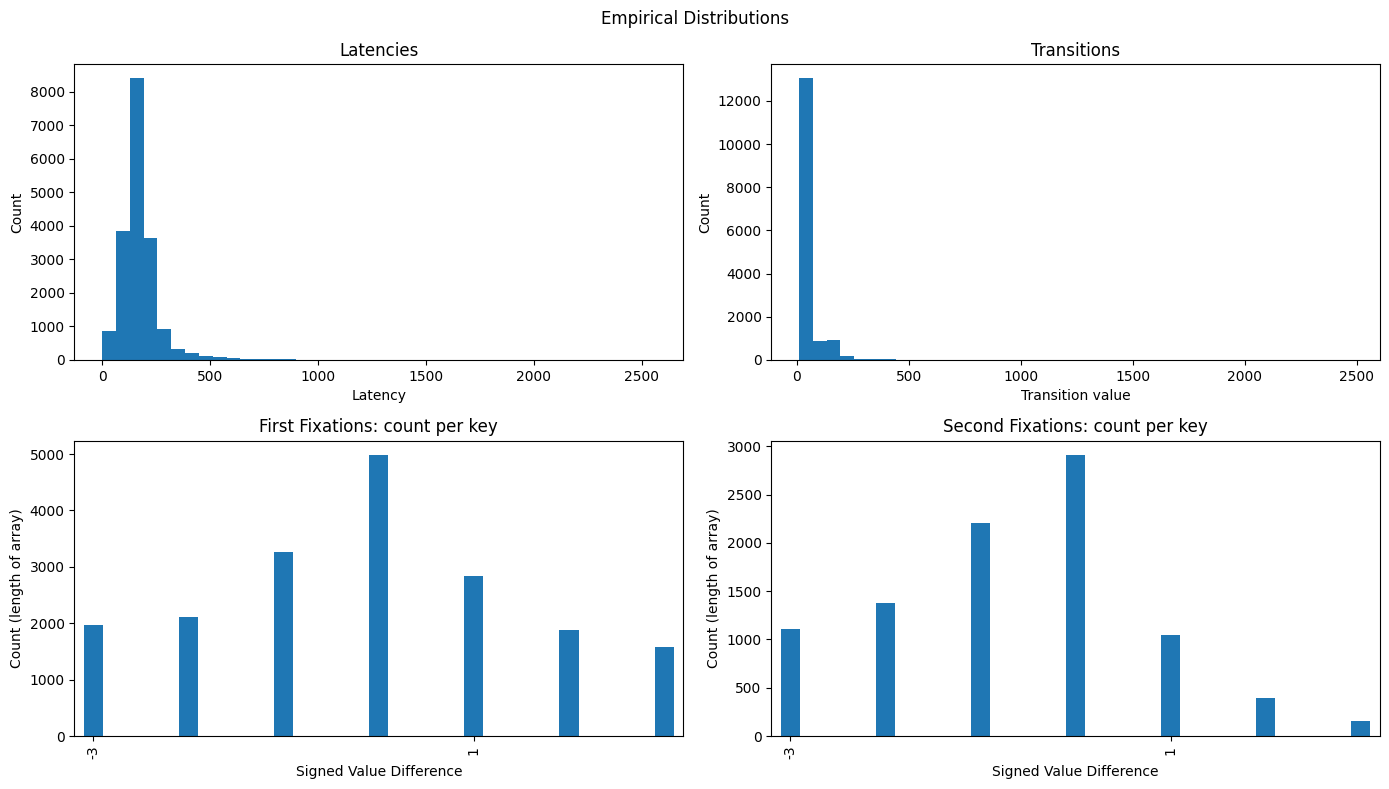

In [33]:
fig, axes = plot_empirical_distributions(empirical_distributions, tick_every=4)
plt.show()

## Comparing empirical distributions

In [ ]:
print(empirical_distributions.keys())
print(new_empirical_distributions.keys())

dict_keys(['probFixLeftFirst', 'latencies', 'transitions', 'fixations'])
dict_keys(['probFixLeftFirst', 'latencies', 'transitions', 'fixations'])


In [38]:
print(empirical_distributions['probFixLeftFirst'])
print(new_empirical_distributions['probFixLeftFirst'])

# Likely, some trials not excluded. This has to be done before feeding into the new get_empirical_distributions

0.7441603535353535
0.7840189023735367


In [ ]:
print(len(empirical_distributions['latencies']))
print(len(new_empirical_distributions['latencies']))

# Not sure why there are a lot more latencies here.

6336
18622


In [ ]:
print(len(empirical_distributions['transitions']))
print(len(new_empirical_distributions['transitions']))

# Okay what is going on???

11798
15178
